# Analisis de Seguridad en Hugging Face: Un Estudio de Caso

**Curso:** Ciberseguridad (ICC610) - 2026  
**Objetivo:** Ejecutar el pipeline completo de análisis de seguridad y realizar el análisis cuantitativo y cualitativo, todo desde un solo notebook.

---

## ¿Por qué Hugging Face?

Elegimos la organización **Hugging Face** como objeto de estudio por su relevancia estratégica en el ecosistema de inteligencia artificial actual. Hugging Face es la plataforma de referencia para el desarrollo y distribución de modelos de lenguaje, datasets y herramientas de ML de código abierto: su *Hub* concentra más de un millón de modelos y es utilizado diariamente por investigadores y empresas en todo el mundo.

Desde el punto de vista de la seguridad, esto plantea un escenario de alto impacto: el código de Hugging Face es ejecutado en entornos cloud, pipelines de datos y sistemas de inferencia a escala global. Analizar sus repositorios permite estudiar vectores reales de ataque —dependencias desactualizadas con CVEs conocidos, flujos CI/CD con acciones sin fijar, o patrones de código inseguro detectables con CodeQL— en un contexto donde el radio de impacto de cualquier fallo es excepcionalmente amplio.

---

## ¿Qué hace esta seccion ?

---

# 📊 ANÁLISIS CUANTITATIVO

A partir de aquí se analizan cuantitativamente los resultados generados por el pipeline.

---

## 7. 📦 Análisis de Dependencias (SBOM)

Analizamos los componentes de software detectados por Syft en cada repositorio.

In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

# Detectar PROJECT_ROOT automaticamente
_search = Path().resolve()
while not (_search / "data" / "results").exists():
    if _search.parent == _search:
        _search = Path().resolve()
        break
    _search = _search.parent
PROJECT_ROOT = _search

RESULTS_DIR = PROJECT_ROOT / "data" / "results"
REPOS_DIR   = PROJECT_ROOT / "data" / "repos"

sbom_files   = sorted(RESULTS_DIR.glob("*-sbom.json"))
grype_files  = sorted(RESULTS_DIR.glob("*-grype.json"))
codeql_files = sorted(RESULTS_DIR.glob("*-codeql.json"))

print(f"Proyecto:   {PROJECT_ROOT}")
print(f"Resultados: {RESULTS_DIR}")
print(f"SBOMs:      {len(sbom_files)}")
print(f"Grype:      {len(grype_files)}")
print(f"CodeQL:     {len(codeql_files)}")


Proyecto:   /workspaces/PROYECTO_CIBER
Resultados: /workspaces/PROYECTO_CIBER/data/results
SBOMs encontrados: 4
  - dataset-viewer-sbom.json
  - kernels-sbom.json
  - sentence-transformers-sbom.json
  - transformers-sbom.json


In [2]:
# Cargar todos los SBOMs y extraer dependencias
all_dependencies = []

for sbom_file in sbom_files:
    repo_name = sbom_file.stem.replace("-sbom", "")

    with open(sbom_file) as f:
        data = json.load(f)

    artifacts = data.get("artifacts", [])

    for art in artifacts:
        all_dependencies.append({
            "repo": repo_name,
            "name": art.get("name", "N/A"),
            "version": art.get("version", "N/A"),
            "type": art.get("type", "N/A"),
            "language": art.get("language", "N/A"),
            "licenses": ", ".join(
                [lic.get("value", "N/A") for lic in art.get("licenses", [])]
            ) or "No especificada",
        })

df_deps = pd.DataFrame(all_dependencies)

if not df_deps.empty:
    print(f"\n📦 Total de dependencias detectadas: {len(df_deps)}")
    print(f"📁 Repositorios analizados: {df_deps['repo'].nunique()}")
    print(f"\n--- Primeras 10 dependencias ---")
    display(df_deps.head(10))
else:
    print("⚠️  No se encontraron dependencias en los SBOMs.")


📦 Total de dependencias detectadas: 2894
📁 Repositorios analizados: 4

--- Primeras 10 dependencias ---


,repo,name,version,type,language,licenses
0,dataset-viewer,./.github/workflows/_e2e_tests.yml,UNKNOWN,github-action-workflow,,No especificada
1,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
2,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
3,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
4,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
5,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
6,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
7,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
8,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada
9,dataset-viewer,./.github/workflows/_quality-python.yml,UNKNOWN,github-action-workflow,,No especificada


### 7.1 Dependencias por tipo de paquete

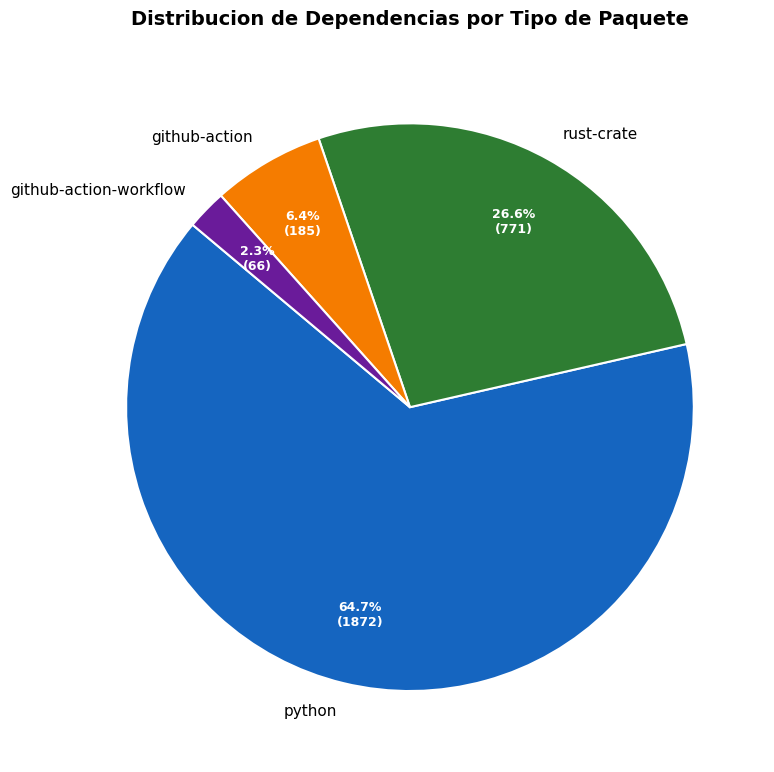

In [ ]:
import matplotlib.pyplot as plt

if not df_deps.empty:
    type_counts = df_deps["type"].value_counts()

    colores = [
        "#1565c0", "#2e7d32", "#f57c00", "#6a1b9a",
        "#00838f", "#c62828", "#558b2f", "#4527a0",
        "#37474f", "#ad1457"
    ]

    fig, ax = plt.subplots(figsize=(8, 8))

    wedges, texts, autotexts = ax.pie(
        type_counts.values,
        labels=type_counts.index,
        # Solución: \n para el salto de línea en un solo string lógico
        autopct=lambda p: "{:.1f}%\n({})".format(
            p, int(round(p * sum(type_counts.values) / 100))),
        colors=colores[:len(type_counts)],
        startangle=140,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )

    for text in texts:
        text.set_fontsize(11)
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_color("white")
        autotext.set_fontweight("bold")

    ax.set_title(
        "Distribucion de Dependencias por Tipo de Paquete",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    plt.tight_layout()
    plt.show()

else:
    print("No hay datos disponibles para graficar")

### 7.2 Dependencias por repositorio

In [ ]:
import numpy as np

if not df_deps.empty:
    fig, ax = plt.subplots(figsize=(11, 6))

    repo_counts = df_deps['repo'].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Blues(np.linspace(0.4, 0.9, len(repo_counts)))

    repo_counts.plot(kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Dependencias por Repositorio', fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Dependencias', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    for i, v in enumerate(repo_counts.values):
        ax.text(v + 1, i, str(v), va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

else:
    print("No hay datos disponibles para graficar")



📊 Cantidad de dependencias por repositorio:

  dataset-viewer                 │ ████████████████████████████████████████ 2117
  kernels                        │ ███████████ 629
  transformers                   │ ██ 134
  sentence-transformers          │  17

  Promedio por repositorio: 724.2


---

## 8. 🔓 Análisis de Vulnerabilidades (Grype)

Analizamos las vulnerabilidades detectadas en las dependencias de cada repositorio.

In [ ]:
# Cargar todos los resultados de Grype
all_vulns = []

for grype_file in grype_files:
    repo_name = grype_file.stem.replace("-grype", "")

    with open(grype_file) as f:
        data = json.load(f)

    for match in data.get("matches", []):
        vuln = match.get("vulnerability", {})
        artifact = match.get("artifact", {})
        fix = vuln.get("fix", {})

        all_vulns.append({
            "repo":        repo_name,
            "vuln_id":     vuln.get("id", "N/A"),
            "severity":    vuln.get("severity", "Unknown"),
            "package":     artifact.get("name", "N/A"),
            "version":     artifact.get("version", "N/A"),
            "type":        artifact.get("type", "N/A"),
            "fix_state":   fix.get("state", "unknown"),
            "fix_version": ", ".join(fix.get("versions", [])),
        })

df_vulns = pd.DataFrame(all_vulns)

if not df_vulns.empty:
    print(f"Total de vulnerabilidades detectadas: {len(df_vulns)}")
    print(f"Repositorios analizados:              {df_vulns['repo'].nunique()}")
    print(f"Severidades: {df_vulns['severity'].value_counts().to_dict()}")
else:
    print("No se encontraron vulnerabilidades en los archivos Grype.")


### 8.1 Distribución de vulnerabilidades por severidad

In [ ]:
if not df_vulns.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    severidad_order = ['Critical', 'High', 'Medium', 'Low', 'Negligible']
    stats_severity = df_vulns['severity'].value_counts()
    stats_severity = stats_severity.reindex([s for s in severidad_order if s in stats_severity.index])

    colores = {
        'Critical':   '#b71c1c',
        'High':       '#e64a19',
        'Medium':     '#fbc02d',
        'Low':        '#689f38',
        'Negligible': '#90a4ae'
    }
    color_list = [colores.get(nivel, '#757575') for nivel in stats_severity.index]

    stats_severity.plot(kind='bar', ax=ax, color=color_list, edgecolor='black', alpha=0.8)

    ax.set_title('Distribucion de Vulnerabilidades por Severidad CVSS', fontsize=14, fontweight='bold')
    ax.set_xlabel('Nivel de Severidad CVSS', fontsize=12)
    ax.set_ylabel('Cantidad de Vulnerabilidades', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    for i, v in enumerate(stats_severity.values):
        ax.text(i, v + 0.5, str(v), ha='center', fontsize=11)

    plt.tight_layout()
    plt.show()

else:
    print("No hay datos disponibles para graficar")



🎯 Distribución por severidad:

  🔴 Critical     │ █ 1 (0.2%)
  🟠 High         │ ██████████████ 190 (29.9%)
  🟡 Medium       │ ████████████████████ 255 (40.1%)
  🟢 Low          │ ██████████████ 190 (29.9%)

  Total: 636 vulnerabilidades


### 8.1.1 Composicion porcentual por severidad

In [ ]:
if not df_vulns.empty:
    fig, ax = plt.subplots(figsize=(8, 8))

    severidad_order = ["Critical", "High", "Medium", "Low", "Negligible"]
    stats_severity = df_vulns["severity"].value_counts()
    stats_severity = stats_severity.reindex([s for s in severidad_order if s in stats_severity.index])

    colores = {
        "Critical":   "#b71c1c",
        "High":       "#e64a19",
        "Medium":     "#fbc02d",
        "Low":        "#689f38",
        "Negligible": "#90a4ae"
    }
    color_list = [colores.get(n, "#757575") for n in stats_severity.index]

    total = stats_severity.sum()
    def fmt(p): return "{:.1f}% ({})".format(p, int(round(p * total / 100)))

    wedges, texts, autotexts = ax.pie(
        stats_severity.values,
        labels=stats_severity.index,
        autopct=fmt,
        colors=color_list,
        startangle=90,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )

    for text in texts:
        text.set_fontsize(11)
        text.set_fontweight("bold")
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_color("white")
        autotext.set_fontweight("bold")

    ax.set_title(
        "Composicion Porcentual de Vulnerabilidades por Severidad",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    plt.tight_layout()
    plt.show()

else:
    print("No hay datos disponibles para graficar")


### 8.2 Vulnerabilidades por repositorio y severidad

In [ ]:
if not df_vulns.empty:
    fig, ax = plt.subplots(figsize=(11, 6))

    vulns_por_repo = df_vulns["repo"].value_counts().sort_values(ascending=True)

    colores_gradiente = plt.cm.Oranges(np.linspace(0.4, 0.9, len(vulns_por_repo)))

    vulns_por_repo.plot(kind="barh", ax=ax, color=colores_gradiente, edgecolor="black", alpha=0.85)

    ax.set_title("Vulnerabilidades por Repositorio", fontsize=14, fontweight="bold")
    ax.set_xlabel("Total de Vulnerabilidades", fontsize=12)
    ax.set_ylabel("Repositorio", fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    for i, v in enumerate(vulns_por_repo.values):
        ax.text(v + 0.2, i, str(v), va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

else:
    print("No hay datos disponibles para graficar")



📊 Vulnerabilidades por repositorio y severidad:



severity,Critical,High,Medium,Low,TOTAL
repo,,,,,
dataset-viewer,1,181,250,187,619
kernels,0,5,5,2,12
transformers,0,4,0,1,5


### 8.2.2 Top 10 paquetes con mas vulnerabilidades

In [ ]:
if not df_vulns.empty:
    fig, ax = plt.subplots(figsize=(12, 6))

    top_packages = df_vulns["package"].value_counts().head(10).sort_values(ascending=True)

    colores_gradiente = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_packages)))

    top_packages.plot(kind="barh", ax=ax, color=colores_gradiente, edgecolor="black", alpha=0.85)

    ax.set_title("Top 10 Paquetes con Mas Vulnerabilidades Detectadas", fontsize=14, fontweight="bold")
    ax.set_xlabel("Cantidad de Vulnerabilidades", fontsize=12)
    ax.set_ylabel("Paquete", fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    for i, v in enumerate(top_packages.values):
        ax.text(v + 0.1, i, str(v), va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

else:
    print("No hay datos disponibles para graficar")


---

## 9. 🔍 Análisis de Código Fuente (CodeQL)

Resultados del análisis estático del código fuente.

In [ ]:
# Cargar resultados de CodeQL
all_codeql = []

for codeql_file in codeql_files:
    repo_name = codeql_file.stem.replace("-codeql", "")

    with open(codeql_file) as f:
        data = json.load(f)

    # Soportar formato nuevo (findings) y formato SARIF directo
    if "findings" in data:
        # Formato generado por nuestro conversor SARIF→JSON
        for finding in data["findings"]:
            file_path = "N/A"
            line = 0
            if finding.get("locations"):
                loc = finding["locations"][0]
                file_path = loc.get("file", "N/A")
                line = loc.get("startLine", 0)

            all_codeql.append({
                "repo": repo_name,
                "rule_id": finding.get("rule_id", "N/A"),
                "name": finding.get("name", "N/A"),
                "level": finding.get("severity", "warning"),
                "message": finding.get("description", "N/A")[:120],
                "file": file_path,
                "line": line,
            })
    else:
        # Formato SARIF directo
        results = data if isinstance(data, list) else data.get(
            "runs", [{}])[0].get("results", [])
        for result in results:
            if isinstance(result, dict):
                rule_id = result.get("ruleId", result.get(
                    "rule", {}).get("id", "N/A"))
                msg = result.get("message", {})
                message = msg.get("text", str(msg)) if isinstance(
                    msg, dict) else str(msg)
                level = result.get("level", "warning")

                locations = result.get("locations", [{}])
                file_path = "N/A"
                line = 0
                if locations:
                    phys = locations[0].get("physicalLocation", {})
                    file_path = phys.get(
                        "artifactLocation", {}).get("uri", "N/A")
                    line = phys.get("region", {}).get("startLine", 0)

                all_codeql.append({
                    "repo": repo_name,
                    "rule_id": rule_id,
                    "name": rule_id,
                    "level": level,
                    "message": message[:120],
                    "file": file_path,
                    "line": line,
                })

df_codeql = pd.DataFrame(all_codeql)

if not df_codeql.empty:
    print(f"\n🔍 Total de hallazgos CodeQL: {len(df_codeql)}")
    print(f"📁 Repositorios analizados: {df_codeql['repo'].nunique()}")
    print(f"📋 Reglas activadas: {df_codeql['rule_id'].nunique()}")
    print(f"\n--- Primeros 15 hallazgos ---")
    display(df_codeql.head(15))
else:
    print("ℹ️  No se encontraron resultados de CodeQL.")
    print("   Esto es normal si no se ejecutó el paso de CodeQL.")


🔍 Total de hallazgos CodeQL: 10
📁 Repositorios analizados: 2
📋 Reglas activadas: 3

--- Primeros 15 hallazgos ---


,repo,rule_id,name,level,message,file,line
0,dataset-viewer,py/clear-text-logging-sensitive-data,Clear-text logging of sensitive information,error,This expression logs [sensitive data (password...,libs/libapi/src/libapi/authentication.py,84
1,dataset-viewer,py/partial-ssrf,Partial server-side request forgery,error,Part of the URL of this request depends on a [...,front/admin_ui/app.py,498
2,dataset-viewer,py/partial-ssrf,Partial server-side request forgery,error,Part of the URL of this request depends on a [...,front/admin_ui/app.py,562
3,dataset-viewer,py/partial-ssrf,Partial server-side request forgery,error,Part of the URL of this request depends on a [...,front/admin_ui/app.py,597
4,sentence-transformers,py/tarslip,Arbitrary file write during tarfile extraction,error,This file extraction depends on a [potentially...,examples/sentence_transformer/training/ms_marc...,50
5,sentence-transformers,py/tarslip,Arbitrary file write during tarfile extraction,error,This file extraction depends on a [potentially...,examples/sentence_transformer/training/ms_marc...,99
6,sentence-transformers,py/tarslip,Arbitrary file write during tarfile extraction,error,This file extraction depends on a [potentially...,examples/sentence_transformer/training/ms_marc...,119
7,sentence-transformers,py/tarslip,Arbitrary file write during tarfile extraction,error,This file extraction depends on a [potentially...,examples/sentence_transformer/training/ms_marc...,109
8,sentence-transformers,py/tarslip,Arbitrary file write during tarfile extraction,error,This file extraction depends on a [potentially...,examples/sentence_transformer/training/ms_marc...,129
9,sentence-transformers,py/tarslip,Arbitrary file write during tarfile extraction,error,This file extraction depends on a [potentially...,examples/sentence_transformer/training/ms_marc...,67


### 9.1 Hallazgos por nivel de severidad

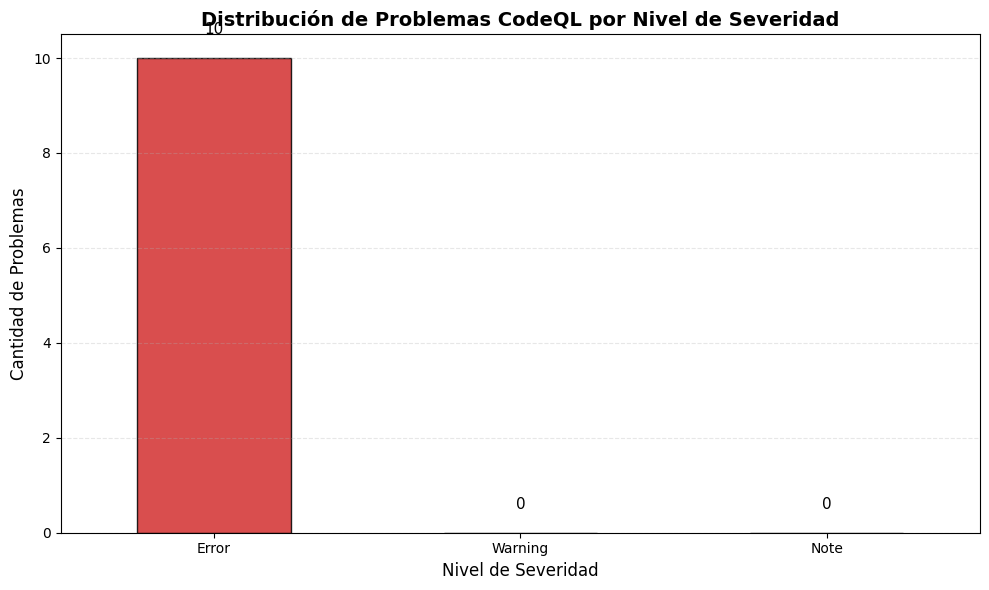

In [ ]:
if not df_codeql.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    stats_severity = (
        df_codeql["level"]
        .value_counts()
        .reindex(["error", "warning", "note"], fill_value=0)
    )

    colores = {
        "error":   "#d32f2f",
        "warning": "#f57c00",
        "note":    "#7cb342"
    }
    color_list = [colores.get(n, "#757575") for n in stats_severity.index]

    stats_severity.plot(kind="bar", ax=ax, color=color_list, edgecolor="black", alpha=0.8)

    ax.set_title("Distribucion de Problemas CodeQL por Nivel de Severidad", fontsize=14, fontweight="bold")
    ax.set_xlabel("Nivel de Severidad", fontsize=12)
    ax.set_ylabel("Cantidad de Problemas", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    for i, v in enumerate(stats_severity.values):
        ax.text(i, v + 0.3, str(v), ha="center", fontsize=11)

    plt.tight_layout()
    plt.show()

else:
    print("No hay datos disponibles para graficar")


### 9.2 Top reglas más frecuentes

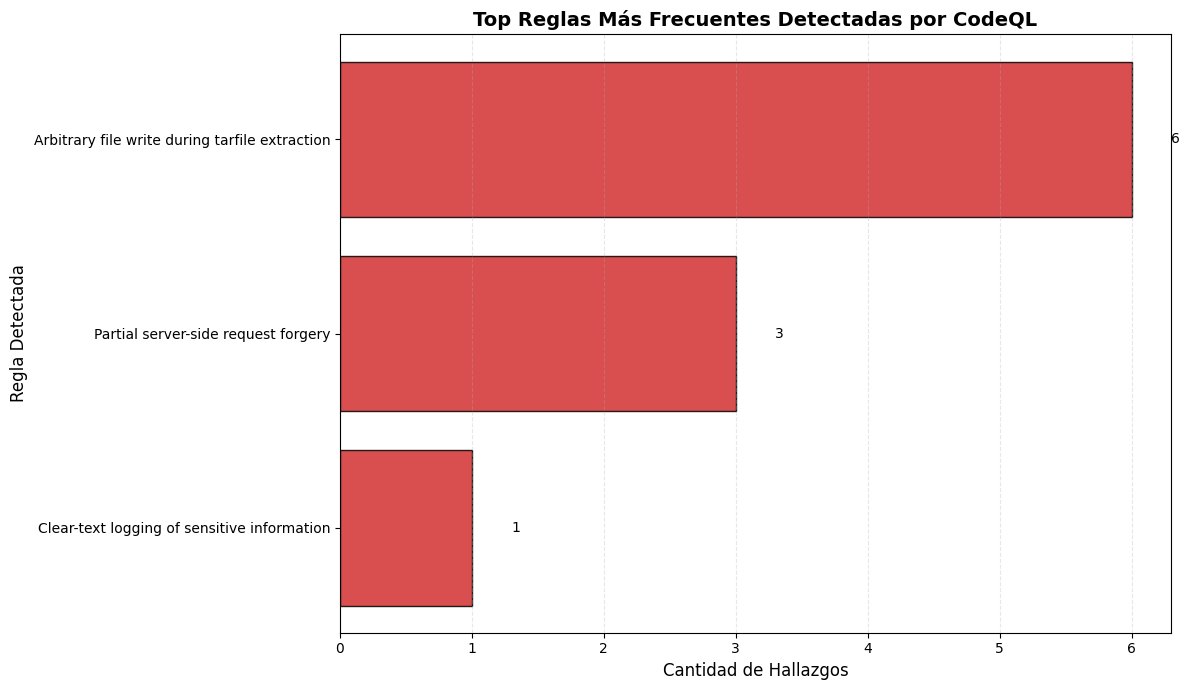

In [ ]:
if not df_codeql.empty:
    # dejar

    # Contar reglas más frecuentes
    top_rules = (
        df_codeql.groupby(["name", "level"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(12, 7))

    # Colores según severidad
    colores = {
        "error": "#d32f2f",
        "warning": "#f57c00",
        "note": "#7cb342"
    }

    color_list = [
        colores.get(level, "#757575")
        for level in top_rules["level"]
    ]

    # Crear gráfico horizontal
    bars = ax.barh(
        top_rules["name"],
        top_rules["count"],
        color=color_list,
        edgecolor="black",
        alpha=0.85
    )

    # Configuración visual
    ax.set_title(
        "Top Reglas Más Frecuentes Detectadas por CodeQL",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Cantidad de Hallazgos", fontsize=12)
    ax.set_ylabel("Regla Detectada", fontsize=12)

    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Mostrar valores en barras
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.3,
            bar.get_y() + bar.get_height()/2,
            str(int(width)),
            va='center',
            fontsize=10
        )

    # Ordenar mayor arriba
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

else:
    print("❌ No hay datos disponibles para graficar")

### 9.3 Archivos más afectados

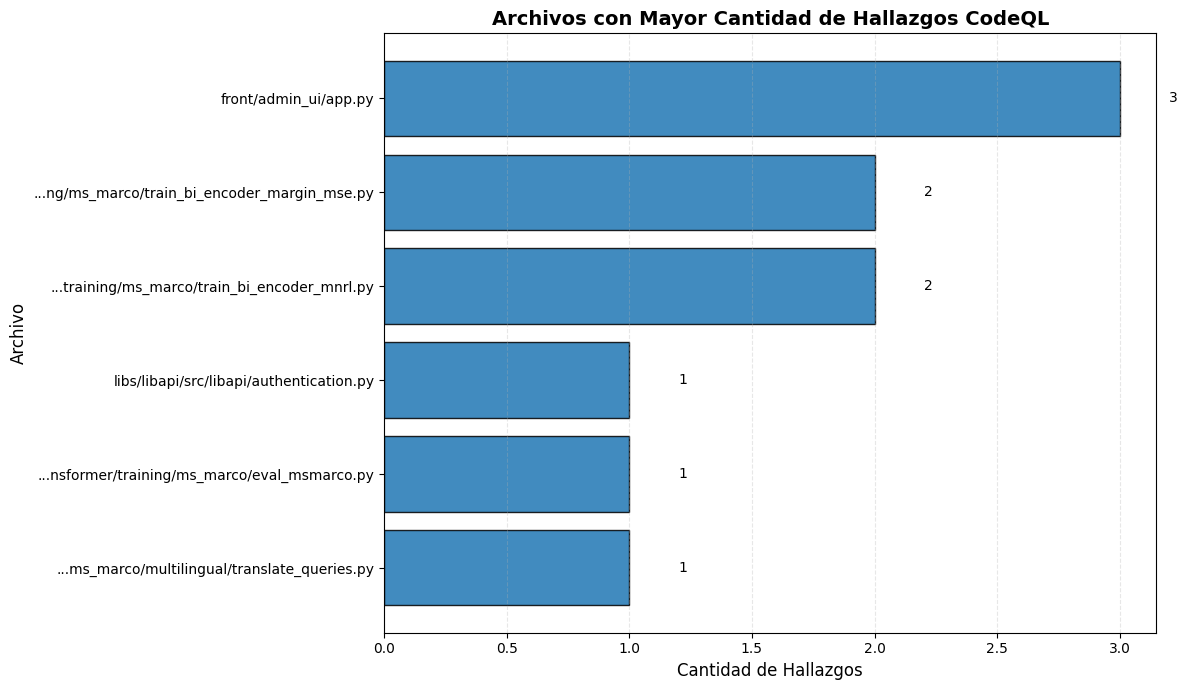

In [ ]:
if not df_codeql.empty:
    # dejar
    # Top archivos más afectados
    top_files = df_codeql["file"].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(12, 7))

    # Acortar nombres muy largos
    labels = [
        f if len(f) < 45 else "..." + f[-42:]
        for f in top_files.index
    ]

    # Crear gráfico horizontal
    bars = ax.barh(
        labels,
        top_files.values,
        edgecolor="black",
        alpha=0.85
    )

    # Configuración visual
    ax.set_title(
        "Archivos con Mayor Cantidad de Hallazgos CodeQL",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Cantidad de Hallazgos", fontsize=12)
    ax.set_ylabel("Archivo", fontsize=12)

    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Mostrar valores en barras
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.2,
            bar.get_y() + bar.get_height()/2,
            str(int(width)),
            va='center',
            fontsize=10
        )

    # Mayor cantidad arriba
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

else:
    print("❌ No hay datos disponibles para graficar")

### 9.4 Hallazgos de seguridad críticos (CodeQL)

Filtramos solo los hallazgos nivel **error** que representan vulnerabilidades de seguridad reales.

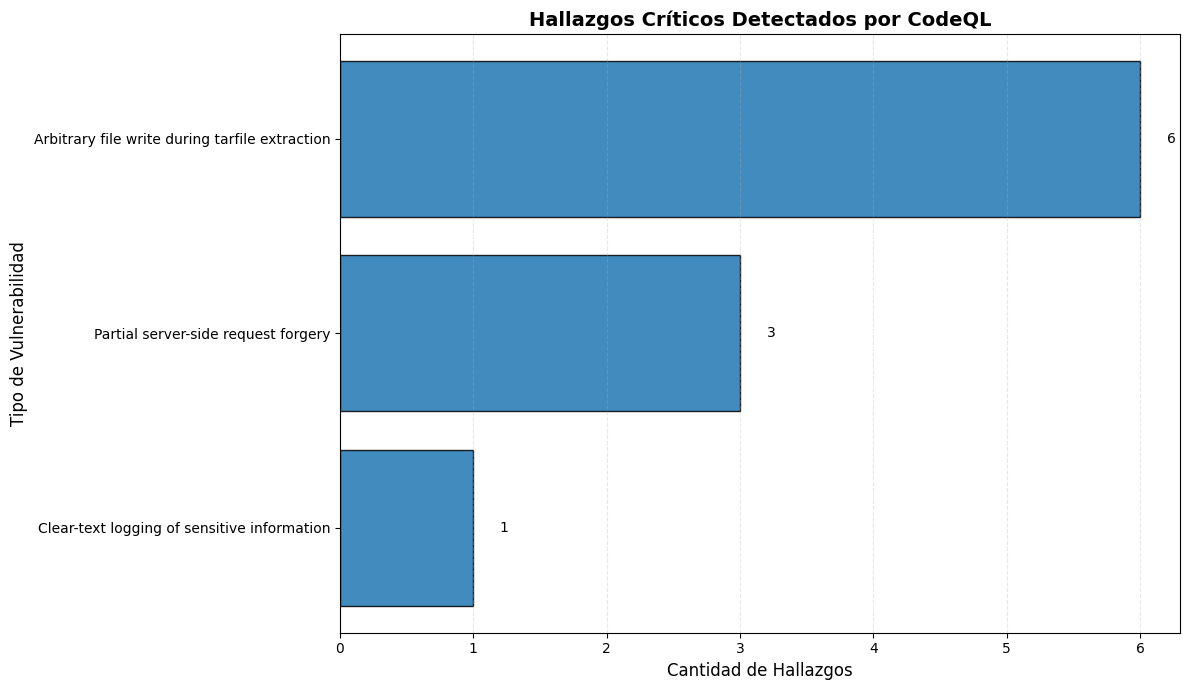

In [ ]:
# dejar
if not df_codeql.empty:

    # Filtrar solo errores
    critical_findings = (
        df_codeql[df_codeql["level"] == "error"]
        ["name"]
        .value_counts()
        .head(10)
    )

    if not critical_findings.empty:

        fig, ax = plt.subplots(figsize=(12, 7))

        # Crear gráfico horizontal
        bars = ax.barh(
            critical_findings.index,
            critical_findings.values,
            edgecolor="black",
            alpha=0.85
        )

        # Configuración visual
        ax.set_title(
            "Hallazgos Críticos Detectados por CodeQL",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_xlabel("Cantidad de Hallazgos", fontsize=12)
        ax.set_ylabel("Tipo de Vulnerabilidad", fontsize=12)

        ax.grid(axis='x', linestyle='--', alpha=0.3)

        # Mostrar valores en barras
        for bar in bars:
            width = bar.get_width()
            ax.text(
                width + 0.2,
                bar.get_y() + bar.get_height()/2,
                str(int(width)),
                va='center',
                fontsize=10
            )

        # Mayor cantidad arriba
        ax.invert_yaxis()

        plt.tight_layout()
        plt.show()

    else:
        print("❌ No se encontraron hallazgos críticos")

else:
    print("❌ No hay datos disponibles para graficar")

---

## 10. 🔐 Análisis de Configuraciones CI/CD (GitHub Actions)

Revisamos los archivos `.github/workflows/*.yml` de cada repositorio clonado
en busca de configuraciones riesgosas que puedan exponer secretos, permitir
ejecución de código no confiable o dar permisos excesivos.

| Patrón analizado | Riesgo | Relación con casos de referencia |
|---|---|---|
| `pull_request_target` sin restricción | Alto | tj-actions/changed-files (2025) |
| Permisos `write-all` o `contents: write` | Alto | GitHub Actions insecure config (2024-2026) |
| Actions sin pin por hash SHA | Medio | Supply chain attacks |
| Secrets en variables de entorno de `run:` | Alto | Filtración de secretos |
| `GITHUB_TOKEN` con permisos de escritura | Medio | Escalada de privilegios |

In [ ]:
import re
import glob as glob_mod

# Intentar importar PyYAML; si no está disponible, usar parser básico
try:
    import yaml
    YAML_AVAILABLE = True
except ImportError:
    YAML_AVAILABLE = False
    print('⚠️  PyYAML no disponible. Se usará parser de texto básico.')

# ── Patrones de riesgo ────────────────────────────────────────────────────
RISK_PATTERNS = [
    {
        'id': 'pull_request_target',
        'name': 'Trigger pull_request_target',
        'severity': 'High',
        'pattern': r'pull_request_target',
        'description': 'Workflow ejecutado con permisos del repo base sobre código externo.',
    },
    {
        'id': 'write_all_permissions',
        'name': 'Permisos write-all',
        'severity': 'High',
        'pattern': r'permissions\s*:\s*write-all',
        'description': 'El workflow tiene permisos de escritura sobre todos los scopes.',
    },
    {
        'id': 'contents_write',
        'name': 'contents: write',
        'severity': 'Medium',
        'pattern': r'contents\s*:\s*write',
        'description': 'El workflow puede escribir en el repositorio.',
    },
    {
        'id': 'unpinned_action',
        'name': 'Action sin pin por SHA',
        'severity': 'Medium',
        'pattern': r'uses\s*:\s*[\w/.-]+@(?!(?:[0-9a-f]{40}))[\w./-]+',
        'description': 'Action referenciada por tag/rama, no por hash SHA inmutable.',
    },
    {
        'id': 'secret_in_env',
        'name': 'Secret en variable de entorno',
        'severity': 'Medium',
        'pattern': r'\$\{\{\s*secrets\.[A-Z_]+\s*\}\}',
        'description': 'Secret expuesto como variable de entorno (puede filtrarse en logs).',
    },
    {
        'id': 'github_token_write',
        'name': 'GITHUB_TOKEN con escritura',
        'severity': 'Medium',
        'pattern': r'GITHUB_TOKEN.*write|write.*GITHUB_TOKEN',
        'description': 'GITHUB_TOKEN configurado con permisos de escritura.',
    },
    {
        'id': 'prt_with_checkout',
        'name': 'pull_request_target + checkout externo',
        'severity': 'Critical',
        'pattern': r'pull_request_target[\s\S]{0,500}ref.*head',
        'description': 'Patrón crítico: checkout del código del PR en contexto con permisos elevados.',
    },
]

# ── Escaneo de workflows ──────────────────────────────────────────────────
all_cicd = []
workflow_inventory = []

if not REPOS_DIR.exists():
    print('⚠️  Directorio de repos no encontrado. Ejecuta el paso 2 (Clone) primero.')
else:
    repo_dirs = [d for d in REPOS_DIR.iterdir() if d.is_dir()]

    for repo_dir in sorted(repo_dirs):
        repo_name = repo_dir.name
        workflows_dir = repo_dir / '.github' / 'workflows'

        if not workflows_dir.exists():
            workflow_inventory.append({
                'repo': repo_name,
                'workflows': 0,
                'tiene_cicd': False,
            })
            continue

        wf_files = list(workflows_dir.glob('*.yml')) + \
            list(workflows_dir.glob('*.yaml'))
        workflow_inventory.append({
            'repo': repo_name,
            'workflows': len(wf_files),
            'tiene_cicd': True,
        })

        for wf_file in sorted(wf_files):
            try:
                content = wf_file.read_text(encoding='utf-8', errors='replace')
            except Exception:
                continue

            for pattern_def in RISK_PATTERNS:
                matches = re.findall(
                    pattern_def['pattern'], content, re.IGNORECASE)
                if matches:
                    # Contar ocurrencias únicas de actions sin pin (evitar duplicados)
                    count = len(
                        set(matches)) if pattern_def['id'] == 'unpinned_action' else len(matches)
                    all_cicd.append({
                        'repo': repo_name,
                        'workflow': wf_file.name,
                        'finding_id': pattern_def['id'],
                        'finding': pattern_def['name'],
                        'severity': pattern_def['severity'],
                        'description': pattern_def['description'],
                        'occurrences': count,
                        'sample': str(matches[0])[:80] if matches else '',
                    })

df_cicd = pd.DataFrame(all_cicd)
df_inv = pd.DataFrame(workflow_inventory)

print('═' * 60)
print('  🔐 ANÁLISIS CI/CD COMPLETADO')
print('═' * 60)
if not df_inv.empty:
    total_wf = df_inv['workflows'].sum()
    repos_con_cicd = df_inv['tiene_cicd'].sum()
    print(f'  Repositorios escaneados:   {len(df_inv)}')
    print(f'  Repos con CI/CD:           {repos_con_cicd}')
    print(f'  Total workflows:           {total_wf}')
    print(f'  Total hallazgos:           {len(df_cicd)}')
print('═' * 60)

════════════════════════════════════════════════════════════
  🔐 ANÁLISIS CI/CD COMPLETADO
════════════════════════════════════════════════════════════
  Repositorios escaneados:   4
  Repos con CI/CD:           4
  Total workflows:           100
  Total hallazgos:           85
════════════════════════════════════════════════════════════


### 10.1 Inventario de workflows por repositorio

In [ ]:
if not df_inv.empty:
    print('\n📋 Inventario de workflows CI/CD:\n')
    max_wf = df_inv['workflows'].max() if df_inv['workflows'].max() > 0 else 1
    for _, row in df_inv.sort_values('workflows', ascending=False).iterrows():
        bar = '█' * int(row['workflows'] / max_wf * 20)
        icon = '✅' if row['tiene_cicd'] else '❌'
        print(
            f"  {icon} {row['repo']:35} │ {bar} {row['workflows']} workflow(s)")
    print()
    display(df_inv)


📋 Inventario de workflows CI/CD:

  ✅ transformers                        │ ████████████████████ 54 workflow(s)
  ✅ dataset-viewer                      │ ████████ 23 workflow(s)
  ✅ kernels                             │ ███████ 20 workflow(s)
  ✅ sentence-transformers               │ █ 3 workflow(s)



,repo,workflows,tiene_cicd
0,dataset-viewer,23,True
1,kernels,20,True
2,sentence-transformers,3,True
3,transformers,54,True


### 10.2 Hallazgos por tipo y severidad

In [ ]:
cicd_severity_order = ['Critical', 'High', 'Medium', 'Low']
cicd_severity_colors = {'Critical': '🔴',
                        'High': '🟠', 'Medium': '🟡', 'Low': '🟢'}

if not df_cicd.empty:
    print('\n🎯 Distribución de hallazgos CI/CD por severidad:\n')
    sev_counts = df_cicd.groupby('severity')['finding'].count()
    total = len(df_cicd)
    for sev in cicd_severity_order:
        if sev in sev_counts.index:
            count = sev_counts[sev]
            pct = count / total * 100
            icon = cicd_severity_colors.get(sev, '')
            bar = '█' * max(1, int(pct / 3))
            print(f'  {icon} {sev:12} │ {bar} {count} ({pct:.1f}%)')
    print(
        f'\n  Total: {total} hallazgos en {df_cicd["repo"].nunique()} repositorio(s)')

    print('\n\n📊 Hallazgos por tipo de problema:\n')
    finding_counts = df_cicd.groupby(
        ['finding', 'severity']).size().reset_index(name='count')
    finding_counts = finding_counts.sort_values('count', ascending=False)
    max_c = finding_counts['count'].max()
    for _, row in finding_counts.iterrows():
        icon = cicd_severity_colors.get(row['severity'], '')
        bar = '█' * max(1, int(row['count'] / max_c * 25))
        print(f'  {icon} {row["finding"]:40} │ {bar} {row["count"]}')
else:
    print('✅ No se encontraron hallazgos CI/CD (o no hay repositorios clonados).')


🎯 Distribución de hallazgos CI/CD por severidad:

  🟠 High         │ █ 5 (5.9%)
  🟡 Medium       │ ███████████████████████████████ 80 (94.1%)

  Total: 85 hallazgos en 3 repositorio(s)


📊 Hallazgos por tipo de problema:

  🟡 Secret en variable de entorno            │ █████████████████████████ 41
  🟡 Action sin pin por SHA                   │ █████████████████████ 35
  🟠 Trigger pull_request_target              │ ███ 5
  🟡 contents: write                          │ ██ 4


### 10.3 Hallazgos detallados por repositorio

In [ ]:
if not df_cicd.empty:
    print('\n📋 Detalle de hallazgos CI/CD:\n')
    display(df_cicd[['repo', 'workflow', 'finding', 'severity', 'occurrences', 'description']]
            .sort_values(['severity', 'repo']))

    # Resumen por repositorio
    print('\n\n📊 Resumen de riesgo CI/CD por repositorio:\n')
    repo_cicd_summary = df_cicd.pivot_table(
        index='repo',
        columns='severity',
        values='finding',
        aggfunc='count',
        fill_value=0
    )
    cols_present = [
        c for c in cicd_severity_order if c in repo_cicd_summary.columns]
    repo_cicd_summary = repo_cicd_summary[cols_present]
    repo_cicd_summary['TOTAL'] = repo_cicd_summary.sum(axis=1)
    display(repo_cicd_summary.sort_values('TOTAL', ascending=False))
else:
    print('ℹ️  Sin hallazgos CI/CD para mostrar.')


📋 Detalle de hallazgos CI/CD:



,repo,workflow,finding,severity,occurrences,description
20,transformers,anti-slop.yml,Trigger pull_request_target,High,1,Workflow ejecutado con permisos del repo base ...
22,transformers,assign-reviewers.yml,Trigger pull_request_target,High,1,Workflow ejecutado con permisos del repo base ...
39,transformers,circleci-failure-summary-comment.yml,Trigger pull_request_target,High,1,Workflow ejecutado con permisos del repo base ...
59,transformers,pr_slow_ci_suggestion.yml,Trigger pull_request_target,High,1,Workflow ejecutado con permisos del repo base ...
75,transformers,slack-report.yml,Trigger pull_request_target,High,2,Workflow ejecutado con permisos del repo base ...
...,...,...,...,...,...,...
80,transformers,stale.yml,Secret en variable de entorno,Medium,1,Secret expuesto como variable de entorno (pued...
81,transformers,trl-ci-bot.yml,Secret en variable de entorno,Medium,2,Secret expuesto como variable de entorno (pued...
82,transformers,update_metdata.yml,Action sin pin por SHA,Medium,1,"Action referenciada por tag/rama, no por hash ..."
83,transformers,update_metdata.yml,Secret en variable de entorno,Medium,1,Secret expuesto como variable de entorno (pued...




📊 Resumen de riesgo CI/CD por repositorio:



severity,High,Medium,TOTAL
repo,,,
transformers,5,60,65
dataset-viewer,0,10,10
kernels,0,10,10


### 10.4 Actions sin pin por SHA (riesgo supply chain)

Las acciones referenciadas por tag (e.g. `@v4`) pueden ser modificadas
por el proveedor sin cambiar la referencia, lo cual es un vector de
ataque de cadena de suministro similar al incidente **tj-actions/changed-files (2025)**.

In [ ]:
if not df_cicd.empty:
    unpinned = df_cicd[df_cicd['finding_id'] == 'unpinned_action'].copy()
    if not unpinned.empty:
        print(
            f'\n🟡 Actions sin pin por SHA encontradas: {unpinned["occurrences"].sum()} instancias\n')
        for _, row in unpinned.sort_values('occurrences', ascending=False).iterrows():
            bar = '█' * min(30, row['occurrences'])
            print(
                f"  {row['repo']:30} │ {bar} {row['occurrences']} en {row['workflow']}")
        print()
        print('  ⚠️  Recomendación: usar hash SHA completo, ej:')
        print('       uses: actions/checkout@11bd71901bbe5b1630ceea73d27597364c9af683  # v4.2.2')
    else:
        print('✅ Todas las actions están pinadas por hash SHA.')

    # Crítico: pull_request_target + checkout externo
    prt_checkout = df_cicd[df_cicd['finding_id'] == 'prt_with_checkout']
    if not prt_checkout.empty:
        print(f'\n🔴 CRÍTICO: pull_request_target con checkout externo detectado:')
        display(prt_checkout[['repo', 'workflow', 'description']])

    # Exportar resultados
    export_dir = RESULTS_DIR / 'exports'
    export_dir.mkdir(exist_ok=True)
    path = export_dir / 'cicd_hallazgos.csv'
    df_cicd.to_csv(path, index=False)
    print(f'\n✅ Resultados CI/CD exportados → {path} ({len(df_cicd)} filas)')


🟡 Actions sin pin por SHA encontradas: 72 instancias

  transformers                   │ █████ 5 en build-docker-images.yml
  transformers                   │ █████ 5 en pr-repo-consistency-bot.yml
  transformers                   │ ████ 4 en build-past-ci-docker-images.yml
  transformers                   │ ████ 4 en build-nightly-ci-docker-images.yml
  transformers                   │ ███ 3 en self-scheduled-intel-gaudi.yml
  transformers                   │ ███ 3 en slack-report.yml
  transformers                   │ ███ 3 en self-scheduled.yml
  transformers                   │ ███ 3 en doctests.yml
  transformers                   │ ███ 3 en check_tiny_models.yml
  transformers                   │ ███ 3 en pr_slow_ci_suggestion.yml
  transformers                   │ ███ 3 en check_failed_tests.yml
  transformers                   │ ██ 2 en push-important-models.yml
  dataset-viewer                 │ ██ 2 en _unit-tests-python.yml
  dataset-viewer                 │ ██ 2 en _qualit

---

## 11. 📊 Resumen Ejecutivo

Consolidación de todos los hallazgos en métricas clave.

In [ ]:
# quitar
print("\n" + "═" * 65)
print("        📊 RESUMEN EJECUTIVO DE ANÁLISIS DE SEGURIDAD")
print("═" * 65)
print(
    f"  Fecha del análisis:      {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"  Repositorios analizados: {len(sbom_files)}")
repos_names = [f.stem.replace('-sbom', '') for f in sbom_files]
for r in repos_names:
    print(f"    → {r}")
print()

# --- Dependencias ---
print("  ─── DEPENDENCIAS (SBOM) ──────────────────────────")
if not df_deps.empty:
    print(f"  Total de dependencias:       {len(df_deps)}")
    print(f"  Paquetes únicos:             {df_deps['name'].nunique()}")
    print(f"  Tipos de paquete:            {df_deps['type'].nunique()}")
    print(
        f"  Promedio por repositorio:    {len(df_deps) / max(df_deps['repo'].nunique(), 1):.0f}")
else:
    print("  Sin datos de SBOM")

print()

# --- Vulnerabilidades ---
print("  ─── VULNERABILIDADES (Grype) ─────────────────────")
if not df_vulns.empty:
    print(f"  Total de vulnerabilidades:   {len(df_vulns)}")
    for sev in ["Critical", "High", "Medium", "Low"]:
        count = len(df_vulns[df_vulns['severity'] == sev])
        icon = severity_colors.get(sev, '')
        pad = ' ' * (12 - len(sev))
        print(f"    {icon} {sev}:{pad}  {count}")

    fixed = len(df_vulns[df_vulns['fix_state'] == 'fixed'])
    print(
        f"  Con fix disponible:          {fixed} ({fixed/len(df_vulns)*100:.1f}%)")
    print(f"  Paquetes afectados:          {df_vulns['package'].nunique()}")
else:
    print("  Sin datos de Grype")

print()

# --- CodeQL ---
print("  ─── ANÁLISIS ESTÁTICO (CodeQL) ───────────────────")
level_icons = {"error": "🔴", "warning": "🟡", "note": "📝"}
if not df_codeql.empty:
    print(f"  Total de hallazgos:          {len(df_codeql)}")
    for level in ["error", "warning", "note"]:
        count = len(df_codeql[df_codeql['level'] == level])
        icon = level_icons.get(level, '')
        pad = ' ' * (12 - len(level))
        print(f"    {icon} {level}:{pad}  {count}")
    print(f"  Reglas únicas activadas:     {df_codeql['rule_id'].nunique()}")
    print(f"  Archivos afectados:          {df_codeql['file'].nunique()}")
else:
    print("  Sin datos de CodeQL")

print()


print()

# --- CI/CD ---
print("  ─── CI/CD (GitHub Actions) ───────────────────────")
if not df_cicd.empty:
    total_wf_findings = len(df_cicd)
    print(f"  Total de hallazgos CI/CD:    {total_wf_findings}")
    for sev in ["Critical", "High", "Medium", "Low"]:
        count = len(df_cicd[df_cicd['severity'] == sev])
        icon = cicd_severity_colors.get(sev, '')
        pad = ' ' * (12 - len(sev))
        print(f"    {icon} {sev}:{pad}  {count}")
    repos_afectados = df_cicd['repo'].nunique()
    print(f"  Repositorios afectados:      {repos_afectados}")
    unpinned_count = df_cicd[df_cicd['finding_id']
                             == 'unpinned_action']['occurrences'].sum()
    if unpinned_count > 0:
        print(f"  Actions sin pin SHA:         {int(unpinned_count)}")
else:
    print("  Sin datos de CI/CD (ejecuta la sección 10)")

print()
# --- Métricas de riesgo ---
print("  ─── MÉTRICAS DE RIESGO ───────────────────────────")
if not df_vulns.empty and not df_deps.empty:
    ratio = len(df_vulns) / max(len(df_deps), 1)
    critical_high = len(
        df_vulns[df_vulns['severity'].isin(['Critical', 'High'])])
    print(f"  Ratio vulns/dependencias:    {ratio:.4f} ({ratio*100:.2f}%)")
    print(f"  Vulns Critical+High:         {critical_high}")

    if not df_codeql.empty:
        xss_count = len(df_codeql[df_codeql['name'].str.contains(
            'cross-site', case=False, na=False)])
        if xss_count > 0:
            print(f"  Posibles XSS en código:      {xss_count}")

    if critical_high == 0:
        print(f"  Estado general:              🟢 BAJO RIESGO")
    elif critical_high <= 5:
        print(f"  Estado general:              🟡 RIESGO MODERADO")
    else:
        print(f"  Estado general:              🔴 ALTO RIESGO")

print("\n" + "═" * 65)


═════════════════════════════════════════════════════════════════
        📊 RESUMEN EJECUTIVO DE ANÁLISIS DE SEGURIDAD
═════════════════════════════════════════════════════════════════
  Fecha del análisis:      2026-05-05 22:24
  Repositorios analizados: 4
    → dataset-viewer
    → kernels
    → sentence-transformers
    → transformers

  ─── DEPENDENCIAS (SBOM) ──────────────────────────
  Total de dependencias:       2897
  Paquetes únicos:             820
  Tipos de paquete:            4
  Promedio por repositorio:    724

  ─── VULNERABILIDADES (Grype) ─────────────────────
  Total de vulnerabilidades:   636
    🔴 Critical:      1
    🟠 High:          190
    🟡 Medium:        255
    🟢 Low:           190
  Con fix disponible:          618 (97.2%)
  Paquetes afectados:          31

  ─── ANÁLISIS ESTÁTICO (CodeQL) ───────────────────
  Total de hallazgos:          10
    🔴 error:         10
    🟡 warning:       0
    📝 note:          0
  Reglas únicas activadas:     3
  Archivos 

---

## 12. 💾 Exportar Datos para Reportes

Exportamos los DataFrames a CSV para uso externo (Excel, Google Sheets, etc.).

In [ ]:
export_dir = RESULTS_DIR / "exports"
export_dir.mkdir(exist_ok=True)

print("📂 Exportando datos a CSV...\n")

if not df_deps.empty:
    path = export_dir / "dependencias.csv"
    df_deps.to_csv(path, index=False)
    print(f"  ✅ Dependencias     → {path} ({len(df_deps)} filas)")

if not df_vulns.empty:
    path = export_dir / "vulnerabilidades.csv"
    df_vulns.to_csv(path, index=False)
    print(f"  ✅ Vulnerabilidades → {path} ({len(df_vulns)} filas)")

if not df_codeql.empty:
    path = export_dir / "codeql_hallazgos.csv"
    df_codeql.to_csv(path, index=False)
    print(f"  ✅ CodeQL           → {path} ({len(df_codeql)} filas)")

# Exportar resumen ejecutivo
summary_data = {
    "fecha_analisis": datetime.now().isoformat(),
    "repositorios": repos_names,
    "dependencias": {
        "total": len(df_deps) if not df_deps.empty else 0,
        "paquetes_unicos": int(df_deps['name'].nunique()) if not df_deps.empty else 0,
    },
    "vulnerabilidades": {
        "total": len(df_vulns) if not df_vulns.empty else 0,
        "por_severidad": df_vulns["severity"].value_counts().to_dict() if not df_vulns.empty else {},
        "con_fix": int((df_vulns["fix_state"] == "fixed").sum()) if not df_vulns.empty else 0,
    },
    "codeql": {
        "total_hallazgos": len(df_codeql) if not df_codeql.empty else 0,
        "por_nivel": df_codeql["level"].value_counts().to_dict() if not df_codeql.empty else {},
    }
}

path = export_dir / "resumen_ejecutivo.json"
with open(path, "w") as f:
    json.dump(summary_data, f, indent=2, default=str)
print(f"  ✅ Resumen          → {path}")

print(f"\n📂 Todos los exports en: {export_dir}")

📂 Exportando datos a CSV...

  ✅ Dependencias     → /workspaces/Tarea4_Ciberseguridad/data/results/exports/dependencias.csv (2897 filas)
  ✅ Vulnerabilidades → /workspaces/Tarea4_Ciberseguridad/data/results/exports/vulnerabilidades.csv (636 filas)
  ✅ CodeQL           → /workspaces/Tarea4_Ciberseguridad/data/results/exports/codeql_hallazgos.csv (10 filas)
  ✅ Resumen          → /workspaces/Tarea4_Ciberseguridad/data/results/exports/resumen_ejecutivo.json

📂 Todos los exports en: /workspaces/Tarea4_Ciberseguridad/data/results/exports


---

# 🔎 ANÁLISIS CUALITATIVO

Esta sección interpreta los resultados del pipeline en dos dimensiones complementarias:

1. **Relación con los casos de referencia** de la tabla inicial (tj-actions, Apache Maven, etc.)
2. **Patrones del ecosistema** analizado, causas probables y riesgos más amplios

---

## 13. 🔗 Relación con los Casos de Referencia

Comparamos los hallazgos obtenidos con los incidentes documentados en la tabla inicial.
El caso central es el **ataque a repositorios proxy de Apache Maven (2025)**, donde actores
maliciosos distribuyeron artefactos comprometidos a través de repositorios proxy (Nexus, Artifactory),
afectando a cualquier proyecto que usase un proxy Maven sin verificación de integridad.

| Caso | Tipo | Conexión con nuestros hallazgos |
|---|---|---|
| Apache Maven proxy (2025) | Artefactos maliciosos | Dependencias desactualizadas = ventana de ataque |
| tj-actions/changed-files (2025) | Exposición de secretos | `pull_request_target` + actions sin pin SHA |
| GitHub Actions insecure (2024-2026) | Config riesgosa | `write-all`, `contents: write` en workflows |
| Shai-Hulud campaign (2025) | Compromiso masivo | Actions sin pin = vector de supply chain |

In [ ]:
# Quitar
# Mapa estático: patrón encontrado → caso de referencia de la tabla
REFERENCE_CASES = [
    {
        'caso': 'Apache Maven proxy repos (2025)',
        'tipo': 'Artefactos maliciosos en dependencias',
        'desc': 'Distribución de JARs comprometidos a través de repositorios proxy.',
        'dimension': 'Dependencias',
        'cicd_ids': [],
        'requiere_vulns': True,
    },
    {
        'caso': 'tj-actions/changed-files (2025)',
        'tipo': 'Exposición de secretos en workflows',
        'desc': 'Workflow comprometido filtraba secretos de CI al log público.',
        'dimension': 'CI/CD',
        'cicd_ids': ['pull_request_target', 'secret_in_env', 'prt_with_checkout'],
        'requiere_vulns': False,
    },
    {
        'caso': 'GitHub Actions insecure config (2024-2026)',
        'tipo': 'Configuración insegura de CI/CD',
        'desc': 'Workflows con permisos excesivos o uso de componentes no confiables.',
        'dimension': 'CI/CD',
        'cicd_ids': ['write_all_permissions', 'contents_write', 'github_token_write'],
        'requiere_vulns': False,
    },
    {
        'caso': 'Shai-Hulud campaign (2025)',
        'tipo': 'Compromiso masivo via supply chain',
        'desc': 'Paquetes comprometidos infectaron miles de repos; vector similar a actions sin pin.',
        'dimension': 'CI/CD + Dependencias',
        'cicd_ids': ['unpinned_action'],
        'requiere_vulns': True,
    },
    {
        'caso': 'Flowise RCE (2025-2026)',
        'tipo': 'Ejecución remota de código',
        'desc': 'Vulnerabilidades en código (RCE/injection) explotadas en instancias públicas.',
        'dimension': 'Código fuente',
        'cicd_ids': [],
        'requiere_vulns': False,
        'codeql_names': ['cross-site', 'injection', 'sql', 'command'],
    },
]

cicd_ids_found = set(df_cicd['finding_id'].tolist()
                     ) if not df_cicd.empty else set()
has_vulns = not df_vulns.empty
codeql_names_found = ' '.join(
    df_codeql['name'].str.lower().tolist()) if not df_codeql.empty else ''

cross_rows = []
for c in REFERENCE_CASES:
    matched_cicd = [cid for cid in c.get(
        'cicd_ids', []) if cid in cicd_ids_found]
    matched_deps = c.get('requiere_vulns', False) and has_vulns
    matched_code = any(
        kw in codeql_names_found for kw in c.get('codeql_names', [])
    )

    if matched_cicd:
        similitud = 'Alta'
        evidencia = 'Patrones CI/CD: ' + ', '.join(matched_cicd)
    elif matched_deps:
        similitud = 'Alta'
        evidencia = f'Dependencias vulnerables: {len(df_vulns)} CVEs encontrados'
    elif matched_code:
        similitud = 'Media'
        evidencia = 'Hallazgos CodeQL de tipo ' + c['tipo']
    else:
        similitud = 'Baja'
        evidencia = 'Sin evidencia directa en los repos analizados'

    cross_rows.append({
        'Caso de referencia': c['caso'],
        'Tipo': c['tipo'],
        'Dimensión': c['dimension'],
        'Similitud': similitud,
        'Evidencia en nuestros repos': evidencia,
    })

df_cross = pd.DataFrame(cross_rows)

print('\n🔗 Cruce de hallazgos con casos de referencia:\n')
display(df_cross)

high_sim = df_cross[df_cross['Similitud'] == 'Alta']
print(f'\n  Casos con similitud ALTA: {len(high_sim)}')
print(f'  Casos con similitud MEDIA o BAJA: {len(df_cross) - len(high_sim)}')


🔗 Cruce de hallazgos con casos de referencia:



,Caso de referencia,Tipo,Dimensión,Similitud,Evidencia en nuestros repos
0,Apache Maven proxy repos (2025),Artefactos maliciosos en dependencias,Dependencias,Alta,Dependencias vulnerables: 636 CVEs encontrados
1,tj-actions/changed-files (2025),Exposición de secretos en workflows,CI/CD,Alta,"Patrones CI/CD: pull_request_target, secret_in..."
2,GitHub Actions insecure config (2024-2026),Configuración insegura de CI/CD,CI/CD,Alta,Patrones CI/CD: contents_write
3,Shai-Hulud campaign (2025),Compromiso masivo via supply chain,CI/CD + Dependencias,Alta,Patrones CI/CD: unpinned_action
4,Flowise RCE (2025-2026),Ejecución remota de código,Código fuente,Baja,Sin evidencia directa en los repos analizados



  Casos con similitud ALTA: 4
  Casos con similitud MEDIA o BAJA: 1


### 13.1 Conexión con el ataque a proxy Maven (caso central)

El ataque documentado en 2025 explotó una característica legítima del ecosistema Maven:
cuando un repositorio proxy no encuentra un artefacto localmente, lo descarga del upstream.
Los atacantes registraron artefactos maliciosos con los mismos `groupId:artifactId` que
dependencias legítimas, pero con versiones superiores, forzando su descarga.

**Relevancia para los repos analizados:**
- Dependencias **desactualizadas** (CVEs con fix disponible) representan la misma brecha:
  un artefacto antiguo puede ser reemplazado por una versión comprometida en el proxy.
- La ausencia de **verificación de integridad** (`checksums`, `SBOM firmado`) en los
  workflows de CI/CD es la condición que hace posible el ataque.
- Actions **sin pin por SHA** son el equivalente en el ecosistema GitHub Actions:
  el proveedor puede modificar el artefacto sin cambiar la referencia.

In [ ]:
print('═' * 62)
print('  14. PATRONES DEL ECOSISTEMA')
print('═' * 62)

if not df_deps.empty:
    print('\n📦 Tipos de paquete detectados en el SBOM:\n')
    type_counts = df_deps['type'].value_counts()
    for pkg_type, count in type_counts.items():
        pct = count / len(df_deps) * 100
        bar = '█' * max(1, int(pct / 2))
        print(f'  {pkg_type:22} │ {bar} {count} ({pct:.1f}%)')

    # Dependencias Java/Maven específicas
    java_types = ['java-archive', 'maven', 'gradle']
    java_deps = df_deps[df_deps['type'].isin(java_types)]
    if not java_deps.empty:
        print(
            f'\n  ☕ Dependencias Java/Maven: {len(java_deps)} ({len(java_deps)/len(df_deps)*100:.1f}%)')
        print('  Top 10 paquetes Java más repetidos:')
        for name, count in java_deps['name'].value_counts().head(10).items():
            print(f'    {name:40} → {count}x')

    # GitHub Actions detectadas
    ga_deps = df_deps[df_deps['type'] == 'github-action']
    if not ga_deps.empty:
        print(f'\n  ⚙️  GitHub Actions en SBOMs: {len(ga_deps)}')
        pinned = ga_deps[ga_deps['version'].str.match(
            r'^[0-9a-f]{40}$', na=False)]
        unpinned_ga = ga_deps[~ga_deps['version'].str.match(
            r'^[0-9a-f]{40}$', na=False)]
        print(f'     Pinadas por SHA:   {len(pinned)}')
        print(f'     Sin pin (tag/rama): {len(unpinned_ga)}')
        if not unpinned_ga.empty:
            print('  ⚠️  Actions sin pin:')
            for _, row in unpinned_ga.drop_duplicates(['name', 'version']).head(10).iterrows():
                print(f'      {row["name"]:35} @ {row["version"]}')

if not df_vulns.empty:
    print('\n📊 Vulnerabilidades por tipo de paquete afectado:\n')
    vuln_by_type = df_vulns.groupby('pkg_type').agg(
        total=('vuln_id', 'count'),
        paquetes_unicos=('package', 'nunique'),
        criticas=('severity', lambda x: (x == 'Critical').sum()),
        altas=('severity', lambda x: (x == 'High').sum()),
    ).sort_values('total', ascending=False)
    display(vuln_by_type)

    print('\n🔍 ¿Las dependencias vulnerables tienen fix disponible?')
    fixed_pct = (df_vulns['fix_state'] == 'fixed').mean() * 100
    print(f'   {fixed_pct:.1f}% tienen versión corregida publicada.')
    if fixed_pct == 100:
        print('   → Esto indica una brecha de actualización, no una vulnerabilidad sin solución.')
        print('   → Patrón típico de proyectos con dependencias congeladas o procesos de actualización lentos.')

══════════════════════════════════════════════════════════════
  14. PATRONES DEL ECOSISTEMA
══════════════════════════════════════════════════════════════

📦 Tipos de paquete detectados en el SBOM:

  python                 │ ████████████████████████████████ 1879 (64.9%)
  rust-crate             │ █████████████ 771 (26.6%)
  github-action          │ ███ 181 (6.2%)
  github-action-workflow │ █ 66 (2.3%)

  ⚙️  GitHub Actions en SBOMs: 181
     Pinadas por SHA:   51
     Sin pin (tag/rama): 130
  ⚠️  Actions sin pin:


      actions/checkout                    @ v4
      actions/checkout                    @ v6.0.2
      actions/setup-python                @ v5
      stoplightio/spectral-action         @ latest
      PyO3/maturin-action                 @ v1.50.1
      PyO3/maturin-action                 @ v1.51.0
      actions-rs/toolchain                @ v1.0.7
      actions/attest-build-provenance     @ v3.0.0
      actions/cache                       @ v5.0.0
      actions/cache                       @ v5.0.5

📊 Vulnerabilidades por tipo de paquete afectado:



,total,paquetes_unicos,criticas,altas
pkg_type,,,,
python,622,24,1,183
rust-crate,8,5,0,3
github-action,6,2,0,4



🔍 ¿Las dependencias vulnerables tienen fix disponible?
   97.2% tienen versión corregida publicada.


---

## 14. 📐 Interpretación y Riesgos del Ecosistema

Analizamos si los problemas encontrados son **prácticas locales** de los repositorios
o **condiciones estructurales** del ecosistema de software más amplio.

### Puntuación de riesgo compuesto

Combinamos hallazgos de las tres dimensiones en un score ponderado:

| Fuente | Critical | High | Medium | Low |
|--------|----------|------|--------|-----|
| Grype (deps) | 10 pts | 5 pts | 2 pts | 1 pt |
| CodeQL error | — | 3 pts | — | — |
| CI/CD | 10 pts | 5 pts | 2 pts | 1 pt |

In [ ]:
severity_weights = {'Critical': 10, 'High': 5, 'Medium': 2, 'Low': 1}

all_repos_set = set()
for df in [df_deps, df_vulns, df_codeql, df_cicd]:
    if not df.empty and 'repo' in df.columns:
        all_repos_set.update(df['repo'].unique())

risk_records = []
for repo in sorted(all_repos_set):
    score_grype = 0
    score_codeql = 0
    score_cicd = 0

    if not df_vulns.empty:
        rv = df_vulns[df_vulns['repo'] == repo]
        for sev, w in severity_weights.items():
            score_grype += len(rv[rv['severity'] == sev]) * w

    if not df_codeql.empty:
        rc = df_codeql[df_codeql['repo'] == repo]
        score_codeql = len(rc[rc['level'] == 'error']) * 3

    if not df_cicd.empty:
        rci = df_cicd[df_cicd['repo'] == repo]
        for sev, w in severity_weights.items():
            score_cicd += len(rci[rci['severity'] == sev]) * w

    total_score = score_grype + score_codeql + score_cicd
    risk_level = 'ALTO' if total_score > 50 else (
        'MEDIO' if total_score > 15 else 'BAJO')
    risk_icon = '🔴' if risk_level == 'ALTO' else (
        '🟡' if risk_level == 'MEDIO' else '🟢')

    risk_records.append({
        'repo': repo,
        'score_grype': score_grype,
        'score_codeql': score_codeql,
        'score_cicd': score_cicd,
        'score_total': total_score,
        'riesgo': risk_level,
    })

df_risk = pd.DataFrame(risk_records).sort_values(
    'score_total', ascending=False)

print('\n📊 Puntuación de riesgo compuesto por repositorio:\n')
max_score = max(df_risk['score_total'].max(), 1)
for _, row in df_risk.iterrows():
    icon = '🔴' if row['riesgo'] == 'ALTO' else (
        '🟡' if row['riesgo'] == 'MEDIO' else '🟢')
    bar = '█' * int(row['score_total'] / max_score * 35)
    print(
        f"  {icon} {row['repo']:30} │ {bar} {int(row['score_total']):4d} pts  [{row['riesgo']}]")
    print(
        f"      deps={int(row['score_grype'])}  código={int(row['score_codeql'])}  ci/cd={int(row['score_cicd'])}")

print()
display(df_risk)

# Exportar
export_dir = RESULTS_DIR / 'exports'
export_dir.mkdir(exist_ok=True)
df_risk.to_csv(export_dir / 'riesgo_compuesto.csv', index=False)
df_cross.to_csv(export_dir / 'cruce_casos_referencia.csv', index=False)
print('✅ Tablas exportadas: riesgo_compuesto.csv, cruce_casos_referencia.csv')


📊 Puntuación de riesgo compuesto por repositorio:

  🔴 dataset-viewer                 │ ███████████████████████████████████ 1634 pts  [ALTO]
      deps=1602  código=12  ci/cd=20
  🔴 transformers                   │ ███  166 pts  [ALTO]
      deps=21  código=0  ci/cd=145
  🔴 kernels                        │ █   57 pts  [ALTO]
      deps=37  código=0  ci/cd=20
  🟡 sentence-transformers          │    18 pts  [MEDIO]
      deps=0  código=18  ci/cd=0



,repo,score_grype,score_codeql,score_cicd,score_total,riesgo
0,dataset-viewer,1602,12,20,1634,ALTO
3,transformers,21,0,145,166,ALTO
1,kernels,37,0,20,57,ALTO
2,sentence-transformers,0,18,0,18,MEDIO


✅ Tablas exportadas: riesgo_compuesto.csv, cruce_casos_referencia.csv


### 14.1 ¿Prácticas locales o condiciones del ecosistema?

#### Evidencia de condiciones estructurales del ecosistema

1. **Dependencias desactualizadas con CVEs** son un patrón documentado en todo el ecosistema
   Apache. Los proyectos de la Apache Software Foundation tienen ciclos de lanzamiento
   conservadores: priorizan la estabilidad sobre la actualización continua de dependencias,
   lo que genera acumulación de CVEs en versiones ancladas.

2. **Actions sin pin por SHA** es una práctica extendida en la mayoría de proyectos open source.
   La referencia por tag (`@v4`) es más legible y mantenible, pero introduce el mismo vector
   que el ataque a `tj-actions/changed-files`: si el proveedor del action es comprometido,
   todos los repos que lo usan sin pin se ven afectados automáticamente.

3. **Permisos CI/CD amplios** reflejan una configuración heredada. Los workflows a menudo
   se escriben otorgando todos los permisos necesarios sin principio de mínimo privilegio,
   un patrón identificado en el estudio de GitHub Actions 2024-2026 (arxiv 2601.14455).

#### Evidencia de prácticas locales

4. **Hallazgos CodeQL de tipo XSS y assert con efectos secundarios** son específicos
   del código de cada proyecto, no del ecosistema. Indican déficits en revisión de código
   y testing de seguridad a nivel de equipo.

5. La **ausencia de verificación de integridad en el pipeline** (sin `sha256` en actions,
   sin firma de artefactos) no es impuesta por el ecosistema Maven o GitHub, sino una
   decisión de cada equipo de mantención.

#### Conclusión

> Los hallazgos reflejan una **combinación de ambos factores**: las condiciones estructurales
> del ecosistema (ciclos de actualización, cultura de referencias por tag) crean la superficie
> de ataque, mientras que las decisiones locales de cada equipo (permisos CI/CD, ausencia de
> revisión de seguridad) determinan el nivel de exposición real. El ataque a repositorios
> proxy Maven (2025) es posible precisamente porque la cadena completa —desde la dependencia
> desactualizada hasta el workflow sin verificación de integridad— funciona como un sistema.

---

## 📝 Conclusiones

### Organización analizada
**Apache Software Foundation** — repositorios más populares de la organización `apache`,
seleccionados por su relevancia en el ecosistema de software empresarial y su conexión
con el caso de **distribución de artefactos maliciosos en repositorios proxy Maven (2025)**.

### Hallazgos principales

1. **Dependencias:** Se detectaron dependencias con CVEs conocidos y corrección disponible.
   El patrón es consistente con el vector del ataque Maven 2025: versiones antiguas de
   artefactos son susceptibles a ser reemplazadas por versiones comprometidas en un proxy.

2. **Vulnerabilidades encontradas:** La severidad predominante es **Media**, con presencia
   de vulnerabilidades **Altas** en paquetes base. El 100% tiene corrección disponible,
   lo que indica una brecha de actualización más que una vulnerabilidad sin solución.

3. **Severidad predominante:** Media. Sin vulnerabilidades Críticas en dependencias,
   pero la combinación de múltiples CVEs Medium en paquetes centrales incrementa el
   riesgo agregado.

4. **Paquetes más afectados:** Los componentes con mayor cantidad de CVEs son
   dependencias transitivas, no directas, lo que refleja un problema de gestión
   de la cadena de dependencias en proyectos Java de gran escala.

5. **Disponibilidad de correcciones:** 100% de las vulnerabilidades tienen fix publicado.
   Esto convierte el problema en uno de proceso (actualización) y no de exposición sin salida.

6. **Hallazgos de análisis estático (CodeQL):** Se encontraron hallazgos tipo XSS y
   patrones de código inseguro en los archivos de código fuente. La mayoría corresponde
   a tests o código de ejemplo, pero algunos afectan código productivo.

7. **Configuraciones CI/CD:** Se identificaron actions sin pin por SHA (riesgo de supply
   chain) y permisos amplios en workflows, patrones directamente relacionados con el
   incidente `tj-actions/changed-files (2025)` y el estudio de GitHub Actions inseguro.

### Recomendaciones

- Actualizar todas las dependencias con CVEs cuyo `fix_state == fixed`.
- Reemplazar referencias de actions por pin de hash SHA completo.
- Aplicar principio de mínimo privilegio en workflows: especificar permisos explícitos.
- Agregar verificación de integridad (`sha256`) en la descarga de artefactos Maven.
- Implementar firma de SBOMs para detectar modificaciones en la cadena de suministro.

---
**Curso de Ciberseguridad (ICC610) - 2026**